# 1. Import les libraries et le dataset

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_dpe = pd.read_csv('/kaggle/input/datasets/vitnguynchong/data-dpe/data_dpe.txt',sep='\\s+')
data_dpe.head()

,type_logement,annee_construction,surface_habitable,type_energie_chauffage,conso_energie,classe_conso_energie,emission_ges
0,1,1988,25,2,300.44,C,13.23
1,1,1996,64,1,148.17,D,34.67
2,1,1970,46,2,257.00,C,12.00
3,2,1958,74,1,317.03,F,74.18
4,1,2013,38,1,53.42,C,12.50


Les variables sélectionnées pour cette étude sont les suivantes :

- **type_logement** : type du logement (1 = appartement, 2 = maison) — variable qualitative.
- **annee_construction** : année de construction du logement — variable quantitative.
- **surface_habitable** : surface habitable en mètres carrés — variable quantitative.
- **type_energie_chauffage** : type d’énergie utilisée pour le chauffage (1 = gaz, 2 = électricité, 3 = autre) — variable qualitative.
- **conso_energie** : consommation énergétique annuelle en kWhEP/m² — variable quantitative.
- **classe_conso_energie** : classe de consommation énergétique (de A à G) — variable qualitative.
- **emission_ges** : émissions de gaz à effet de serre en kg éq.CO₂/m² — variable quantitative.

##  2. Analyse descriptive

### 2.1 Variables quantitatives

#### 2.1.1 Ancienneté

In [4]:
data_dpe['anciennete'] = 2021 - data_dpe['annee_construction']
data_dpe['anciennete'].describe()

count    1000.000000
mean       34.578000
std        25.877743
min         1.000000
25%        15.000000
50%        32.000000
75%        51.000000
max       121.000000
Name: anciennete, dtype: float64

In [5]:
anciennete = data_dpe['anciennete']
round(anciennete.std(), 2)

25.88

In [6]:
cv = round((anciennete.std() / anciennete.mean()) * 100)
cv

75

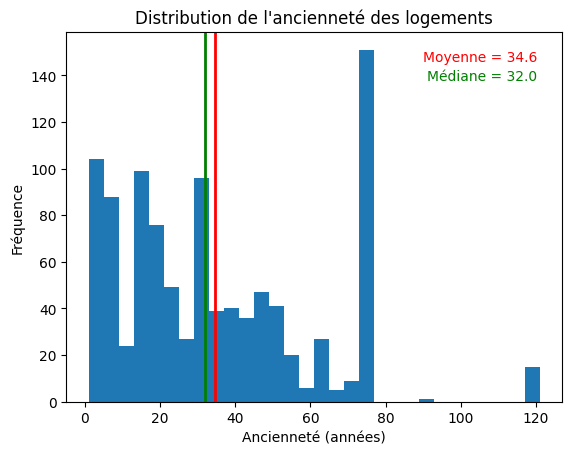

In [38]:
moyenne = data_dpe['anciennete'].mean()
mediane = data_dpe['anciennete'].median()

plt.hist(data_dpe['anciennete'], bins=30)

plt.title("Distribution de l'ancienneté des logements")
plt.xlabel("Ancienneté (années)")
plt.ylabel("Fréquence")

plt.axvline(moyenne, linewidth=2,color='red')
plt.text(0.95, 0.95,
         f"Moyenne = {round(moyenne,1)}",
         transform=plt.gca().transAxes,ha='right', va='top',color='red')

plt.axvline(mediane, linewidth=2,color='green')
plt.text(0.95, 0.90,
         f"Médiane = {round(mediane,1)}",
         transform=plt.gca().transAxes, ha='right', va='top',color='green')
plt.show()

#### 2.1.2 Surface habitable

In [8]:
data_dpe['surface_habitable'].describe()

count    1000.000000
mean       82.514000
std        94.874069
min        16.000000
25%        45.750000
50%        66.000000
75%        95.250000
max      1452.000000
Name: surface_habitable, dtype: float64

In [9]:
# écart-type
sd_surface = data_dpe['surface_habitable'].std()
print(sd_surface)

# Coefficient de variation
cv = round((sd_surface / data_dpe['surface_habitable'].mean()) * 100)
print(cv)

94.87406860092435
115


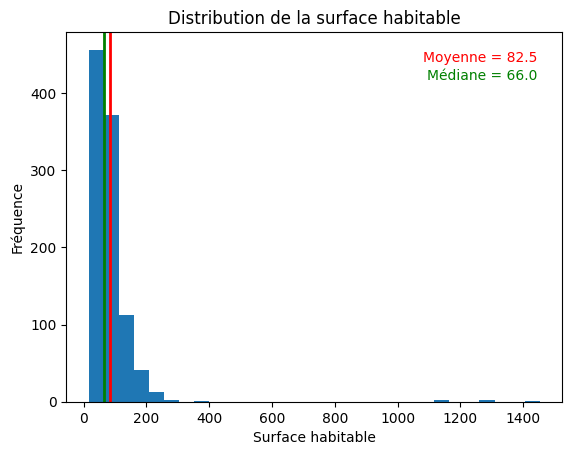

In [39]:
moyenne = data_dpe['surface_habitable'].mean()
mediane = data_dpe['surface_habitable'].median()

plt.hist(data_dpe['surface_habitable'], bins=30)

plt.title("Distribution de la surface habitable")
plt.xlabel("Surface habitable")
plt.ylabel("Fréquence")

# Moyenne
plt.axvline(moyenne, linewidth=2,color='red')
plt.text(0.95, 0.95,
         f"Moyenne = {round(moyenne,1)}",
         transform=plt.gca().transAxes,ha='right', va='top',color='red')

# Mediane
plt.axvline(mediane, linewidth=2,color='green')
plt.text(0.95, 0.90,
         f"Médiane = {round(mediane,1)}",
         transform=plt.gca().transAxes, ha='right', va='top',color='green')
plt.show()

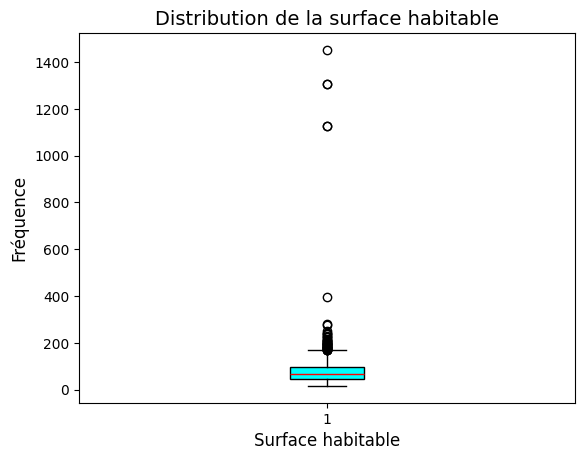

In [11]:
plt.boxplot(data_dpe['surface_habitable'],
            patch_artist=True,  
            boxprops=dict(facecolor='cyan', color='black'),
            medianprops=dict(color='red'))

plt.title("Distribution de la surface habitable", fontsize=14)
plt.xlabel("Surface habitable", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.show()

#### 2.1.3 Consommation d’énergie

In [19]:
data_dpe['conso_energie'].describe()

count    1000.000000
mean      184.119070
std        96.891905
min        27.920000
25%       114.735000
50%       181.165000
75%       238.245000
max       591.350000
Name: conso_energie, dtype: float64

In [20]:
# Écart type
sd_conso_energie = data_dpe['conso_energie'].std()
print(sd_conso_energie)

# Coefficient de variation
cv = round((sd_conso_energie/ data_dpe['conso_energie'].mean()) * 100)
print(cv)

96.89190515063082
53


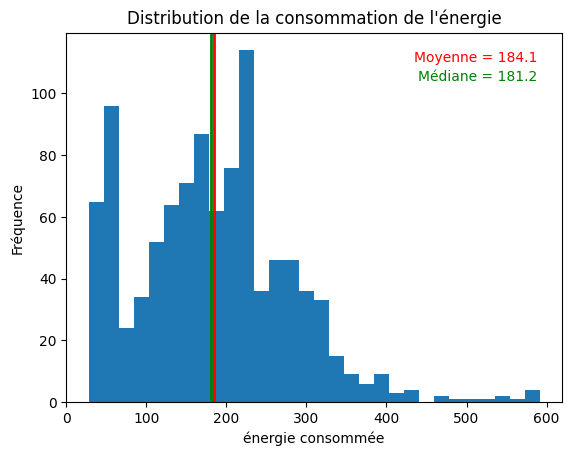

In [35]:
moyenne = data_dpe["conso_energie"].mean()
mediane = data_dpe["conso_energie"].median()

plt.hist(data_dpe["conso_energie"], bins=30)

plt.title("Distribution de la consommation de l'énergie")
plt.xlabel("énergie consommée")
plt.ylabel("Fréquence")

# Moyenne 
plt.axvline(moyenne, linewidth=2,color='red')
plt.text(0.95, 0.95,
         f"Moyenne = {round(moyenne,1)}",
         transform=plt.gca().transAxes,ha='right', va='top',color='red')

# Mediane
plt.axvline(mediane, linewidth=2,color='green')
plt.text(0.95, 0.90,
         f"Médiane = {round(mediane,1)}",
         transform=plt.gca().transAxes, ha='right', va='top',color='green')
plt.show()

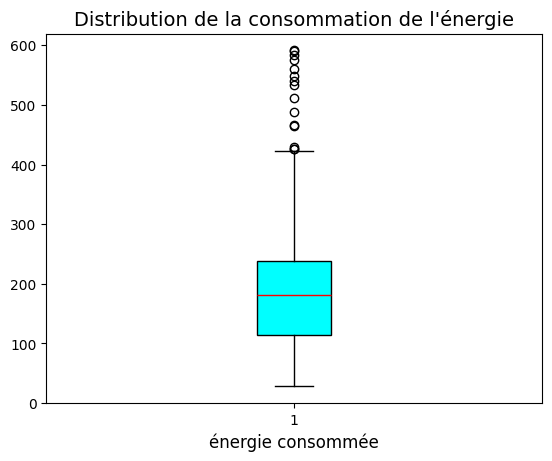

In [27]:
plt.boxplot(data_dpe['conso_energie'],
            patch_artist=True, 
            boxprops=dict(facecolor='cyan', color='black'),
            medianprops=dict(color='red'))

plt.title("Distribution de la consommation de l'énergie", fontsize=14)
plt.xlabel("énergie consommée", fontsize=12)

plt.show()

#### 2.1.4 Émission de GES

In [28]:
data_dpe['emission_ges'].describe()

count    1000.000000
mean       21.932580
std        20.649155
min         2.000000
25%         8.602500
50%        12.695000
75%        30.000000
max       143.360000
Name: emission_ges, dtype: float64

In [29]:
# Écart-type
sd_emission_ges = data_dpe['emission_ges'].std()
print(sd_emission_ges)

# Coefficient de variation
cv = round((sd_emission_ges/ data_dpe['emission_ges'].mean()) * 100)
print(cv)

20.64915509045223
94


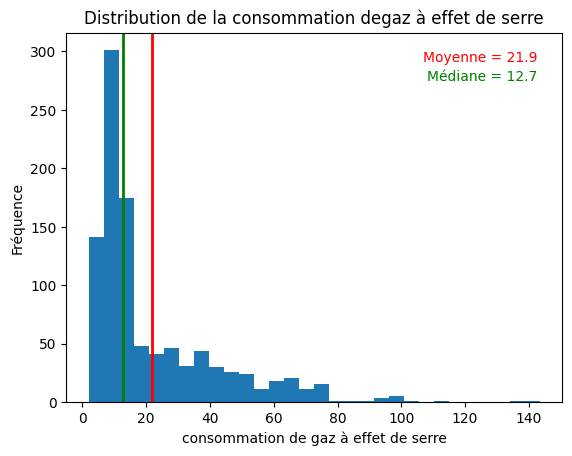

In [40]:
moyenne = data_dpe['emission_ges'].mean()
mediane = data_dpe['emission_ges'].median()

plt.hist(data_dpe['emission_ges'], bins=30)

plt.title("Distribution de la consommation degaz à effet de serre")
plt.xlabel("consommation de gaz à effet de serre") 
plt.ylabel("Fréquence")

# Moyenne
plt.axvline(moyenne, linewidth=2,color='red')
plt.text(0.95, 0.95,
         f"Moyenne = {round(moyenne,1)}",
         transform=plt.gca().transAxes,ha='right', va='top',color='red')

# Mediane
plt.axvline(mediane, linewidth=2,color='green')
plt.text(0.95, 0.90,
         f"Médiane = {round(mediane,1)}",
         transform=plt.gca().transAxes, ha='right', va='top',color='green')
plt.show()

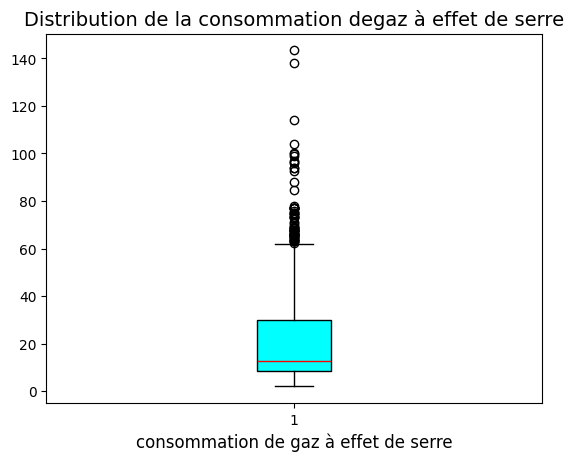

In [41]:
plt.boxplot(data_dpe['emission_ges'],
            patch_artist=True,  
            boxprops=dict(facecolor='cyan', color='black'),
            medianprops=dict(color='red'))

plt.title("Distribution de la consommation degaz à effet de serre", fontsize=14)
plt.xlabel("consommation de gaz à effet de serre", fontsize=12)

plt.show()

### 2.1 Variables qualitatives

#### 2.2.1 Le type de logement

In [42]:
data_dpe["type_logement"] = pd.Categorical(
    data_dpe["type_logement"],
    categories=[1, 2],
    ordered=False)

data_dpe["type_logement"] = data_dpe["type_logement"].cat.rename_categories(
    ["appartement", "maison"])

data_dpe["type_logement"].value_counts()

type_logement
appartement    639
maison         361
Name: count, dtype: int64

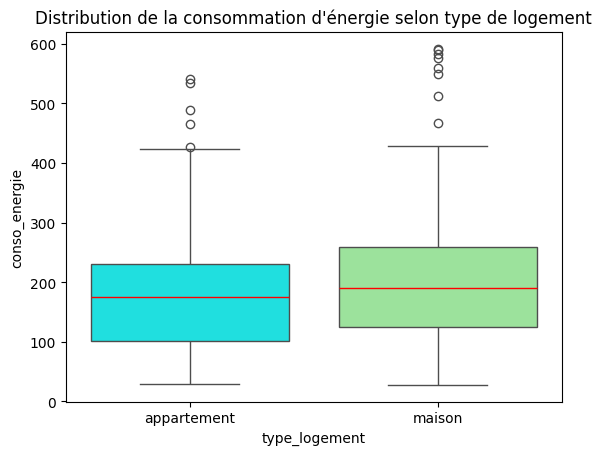

In [49]:
sns.boxplot(x="type_logement", y="conso_energie", hue="type_logement",
            data=data_dpe, palette={"appartement":"cyan","maison":"lightgreen"},
            dodge=False, medianprops={"color":"red"})  
plt.legend([],[], frameon=False)  
plt.title("Distribution de la consommation d'énergie selon type de logement")
plt.show()

#### 2.2.2 Le type de l’energie chauffage

In [62]:
data_dpe["type_energie_chauffage"] = data_dpe["type_energie_chauffage"].map({
    1: "gaz",
    2: "électricité",
    3: "autre"
})

In [63]:
data_dpe["type_energie_chauffage"] = pd.Categorical(
    data_dpe["type_energie_chauffage"],
    categories=["gaz", "électricité", "autre"],
    ordered=False)

data_dpe["type_energie_chauffage"].value_counts()

type_energie_chauffage
électricité    542
gaz            433
autre           25
Name: count, dtype: int64

Text(0, 0.5, 'Frequence')

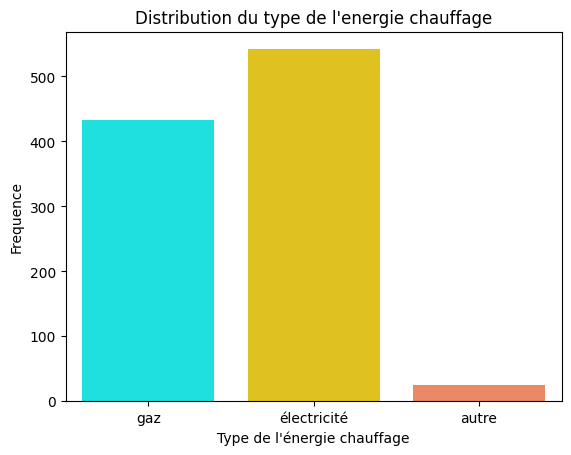

In [68]:
sns.countplot(x="type_energie_chauffage", data=data_dpe, hue="type_energie_chauffage",
              palette=["cyan","gold","coral"])

plt.title("Distribution du type de l'energie chauffage")
plt.xlabel("Type de l'énergie chauffage")
plt.ylabel("Frequence")

#### 2.2.3 La classe de la consommation d’énergie

In [72]:
data_dpe["classe_conso_energie"].value_counts().reindex(["A","B","C","D","E","F","G"])

classe_conso_energie
A     98
B    295
C    274
D    121
E    127
F     70
G     15
Name: count, dtype: int64

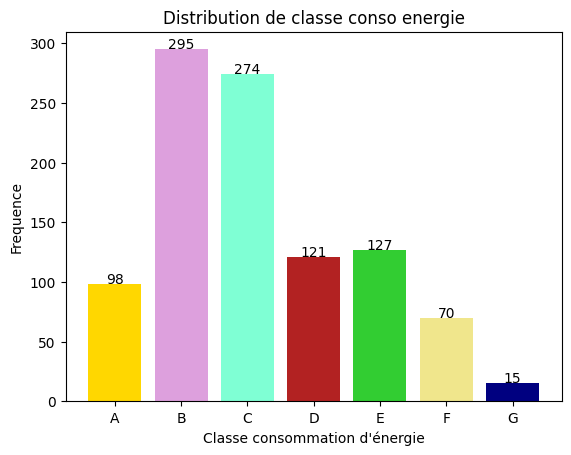

In [77]:
counts = data_dpe["classe_conso_energie"].value_counts().sort_index()

plt.bar(counts.index, counts.values, 
        color=["gold","plum","aquamarine","firebrick","limegreen","khaki","navy"])


plt.title("Distribution de classe conso energie")
plt.xlabel("Classe consommation d'énergie")
plt.ylabel("Frequence")

for i, val in enumerate(counts.values):
    plt.text(i, val + 0.5, str(val), ha='center', fontsize=10)

plt.show()


##  3. Analyse en composantes principales (ACP)

In [78]:
housing = data_dpe.copy()  
data = housing[["annee_construction", "surface_habitable", "conso_energie", "emission_ges"]]

In [79]:
data.head()  
data.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   annee_construction  1000 non-null   int64  
 1   surface_habitable   1000 non-null   int64  
 2   conso_energie       1000 non-null   float64
 3   emission_ges        1000 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 31.4 KB


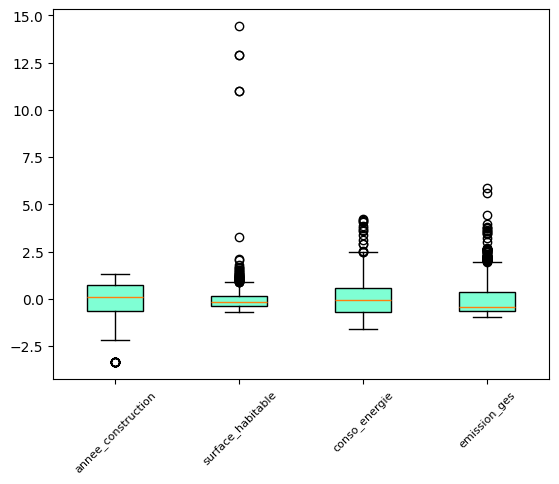

In [81]:
m = data.mean()        
s = data.std()         
X = (data - m) / s     

plt.boxplot(X.values, tick_labels=X.columns, patch_artist=True,
            boxprops=dict(facecolor="aquamarine"))
plt.xticks(rotation=45, fontsize=8)  # las=1, cex.axis
plt.show()

### 3.1 La matrice de covariance

In [82]:
# Méthode 1: Numpy
X_matrix = X.values      
V = np.corrcoef(X_matrix, rowvar=False)  
V_rounded = np.round(V, 2)

print(V_rounded)

[[ 1.   -0.01 -0.49 -0.51]
 [-0.01  1.   -0.13  0.02]
 [-0.49 -0.13  1.    0.44]
 [-0.51  0.02  0.44  1.  ]]


Méthode 2: Pandas


V = X.corr()          
V_rounded = V.round(2)  

print(V_rounded)

### 3.2 Les valeur propre 

In [84]:
eigvals, eigvecs = np.linalg.eigh(V_rounded)

# on range dans ordre
eigvals_sorted = np.sort(eigvals)[::-1]

eigvals_rounded = np.round(eigvals_sorted, 2)

print(eigvals_rounded)

[1.96 1.03 0.54 0.47]


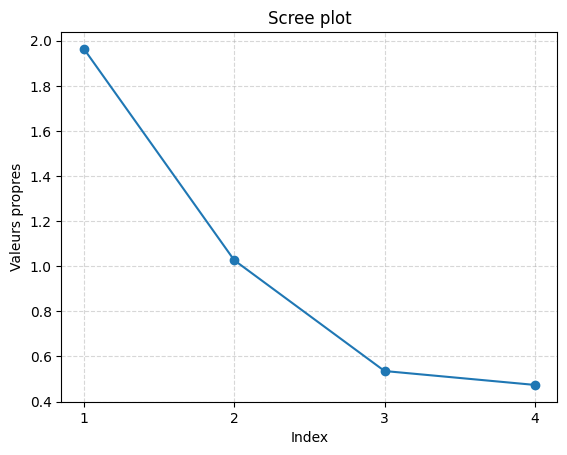

In [85]:
plt.plot(range(1, len(eigvals_sorted)+1), eigvals_sorted, marker='o', linestyle='-')
plt.ylabel("Valeurs propres")
plt.xlabel("Index")
plt.title("Scree plot")
plt.xticks(range(1, len(eigvals_sorted)+1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [86]:

n_features = X.shape[1]

cumulative_variance_ratio = np.cumsum(eigvals_sorted) / n_features

print(np.round(cumulative_variance_ratio, 2))

[0.49 0.75 0.88 1.  ]


In [92]:
# eigvals, eigvecs  np.linalg.eigh
eigvals, eigvecs = np.linalg.eigh(V_rounded)

# on range dans l'ordre eigenvalues 
idx = np.argsort(eigvals)[::-1]    
eigvals_sorted = eigvals[idx]
eigvecs_sorted = eigvecs[:, idx]

eigvecs_rounded = np.round(eigvecs_sorted, 2)

eigvecs_df = pd.DataFrame(eigvecs_rounded, columns=X.columns)
print(eigvecs_df)

   annee_construction  surface_habitable  conso_energie  emission_ges
0               -0.59              -0.11           0.02         -0.80
1               -0.06               0.97          -0.22         -0.10
2                0.57              -0.17          -0.69         -0.41
3                0.57               0.15           0.69         -0.42


In [94]:
# Méthode 1
#  Projections (scores)
Y = X.values @ eigvecs_sorted   # X %*% E$vectors
Y_df = pd.DataFrame(Y, columns=[f"PC{i+1}" for i in range(Y.shape[1])])

#  D = diag(sqrt(eigenvalues))
k = 2
D = np.diag(np.sqrt(eigvals_sorted))
C = eigvecs_sorted @ D[:, :k]   #  E$vectors %*% D[,1:k]

#  Méthode 2: correlation X vs Y[,1:k]
C2 = np.corrcoef(X.values.T, Y[:, :k].T)[:X.shape[1], X.shape[1]:]  # matrice correlation

# Verifier
diff = C2 - C[:, :k]

print("C2 (correlation directe):\n", np.round(C2, 2))
print("C (E$vectors * sqrt(E$values)):\n", np.round(C[:, :k], 2))
print("Diff = C2 - C:\n", np.round(diff, 2))

C2 (correlation directe):
 [[-0.83 -0.11]
 [-0.09  0.98]
 [ 0.8  -0.17]
 [ 0.8   0.15]]
C (E$vectors * sqrt(E$values)):
 [[-0.83 -0.12]
 [-0.08  0.98]
 [ 0.8  -0.17]
 [ 0.8   0.15]]
Diff = C2 - C:
 [[ 0.  0.]
 [-0. -0.]
 [ 0. -0.]
 [-0. -0.]]


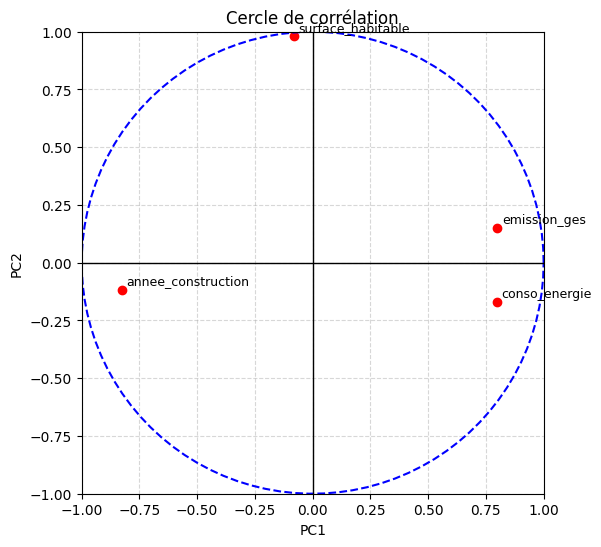

In [95]:
import matplotlib.pyplot as plt
import numpy as np


# Column 0 = PC1, Column 1 = PC2
x = C[:, 0]
y = C[:, 1]
labels = X.columns  

plt.figure(figsize=(6,6))
plt.scatter(x, y, color='red')


for i, label in enumerate(labels):
    plt.text(x[i]+0.02, y[i]+0.02, label, fontsize=9)


theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='blue')

# X et Y
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.gca().set_aspect('equal', adjustable='box')  # asp = 1
plt.title("Cercle de corrélation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#####  Relations entre les variables (Corrélations)

La distance et l’angle entre les points (variables) indiquent leur niveau de corrélation :

- **Corrélation positive** : *emission_ges* (émissions de gaz à effet de serre) et *conso_energie* (consommation d’énergie) sont très proches l’une de l’autre. Cela signifie qu’elles sont positivement corrélées : les logements qui consomment beaucoup d’énergie ont généralement des émissions élevées.

- **Corrélation négative** : *annee_construction* (année de construction) est situé à l’opposé du groupe énergie/émissions par rapport au centre du cercle (selon l’axe horizontal). Cela suggère que les bâtiments plus anciens (année de construction plus faible) ont tendance à consommer davantage d’énergie et à émettre plus de gaz à effet de serre.

- **Indépendance (absence de corrélation)** : *surface_habitable* (surface habitable) est proche de l’axe vertical, formant un angle proche de 90° avec les autres variables. Cela signifie que, dans cet ensemble de données, la surface du logement est peu liée à l’année de construction ou à la performance énergétique par unité de surface.

In [96]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = data.copy()

# 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. PCA avec k components
pca = PCA(n_components=2)  
Y = pca.fit_transform(X_scaled)  # scores (PCs)

# 3. Eigenvalues & proportion of variance
eigvals = pca.explained_variance_            # eigenvalues
explained_ratio = pca.explained_variance_ratio_  # % variance explained

# 4.
loadings = pca.components_.T
loadings_df = pd.DataFrame(loadings, index=X.columns, columns=[f"PC{i+1}" for i in range(loadings.shape[1])])

print("Scores (Y):")
print(pd.DataFrame(Y, columns=[f"PC{i+1}" for i in range(Y.shape[1])]).head())

print("\nLoadings (C):")
print(loadings_df.round(2))

print("\nExplained variance ratio:")
print(np.round(explained_ratio, 2))

Scores (Y):
        PC1       PC2
0 -0.447276 -0.850355
1  0.066396 -0.079792
2 -0.554346 -0.492462
3 -2.875295  0.200303
4  1.604580 -0.425929

Loadings (C):
                     PC1   PC2
annee_construction  0.59 -0.12
surface_habitable   0.06  0.97
conso_energie      -0.57 -0.16
emission_ges       -0.57  0.15

Explained variance ratio:
[0.49 0.26]


##  4. Analyse des correspondances multiples (ACM)

In [97]:
house = data_dpe.copy()  
data2 = house[["type_logement","type_energie_chauffage","classe_conso_energie"]]

In [102]:
data1 = data_dpe[["type_logement", "type_energie_chauffage", "classe_conso_energie"]].copy()
data1["type_logement"] = data1["type_logement"].astype("category")
data1["type_energie_chauffage"] = data1["type_energie_chauffage"].astype("category")
data1["classe_conso_energie"] = data1["classe_conso_energie"].astype("category")

In [105]:
# on resume
for col in data1.columns:
    print(f"--- {col} ---")
    print(data1[col].value_counts())
    print()

--- type_logement ---
type_logement
1    639
2    361
Name: count, dtype: int64

--- type_energie_chauffage ---
type_energie_chauffage
électricité    542
gaz            433
autre           25
Name: count, dtype: int64

--- classe_conso_energie ---
classe_conso_energie
B    295
C    274
E    127
D    121
A     98
F     70
G     15
Name: count, dtype: int64



In [106]:
!pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 6.0 MB/s eta 0:00:00


In [109]:
import prince
import pandas as pd
import numpy as np

# MCA
mca = prince.MCA(n_components=5, n_iter=10, copy=True, engine='scipy', random_state=42)
mca = mca.fit(data1)

# Eigenvalues
eigvals = np.array(mca.eigenvalues_)

# % variance & cumulative
perc_var = eigvals / eigvals.sum() * 100
cum_var = np.cumsum(perc_var)

eig_df = pd.DataFrame({
    "eigenvalue": np.round(eigvals, 6),
    "percentage of variance": np.round(perc_var, 2),
    "cumulative % of variance": np.round(cum_var, 2)
}, index=[f"dim {i+1}" for i in range(len(eigvals))])

print(eig_df)

       eigenvalue  percentage of variance  cumulative % of variance
dim 1    0.565405                   27.76                     27.76
dim 2    0.439783                   21.59                     49.35
dim 3    0.365188                   17.93                     67.27
dim 4    0.333333                   16.36                     83.64
dim 5    0.333333                   16.36                    100.00


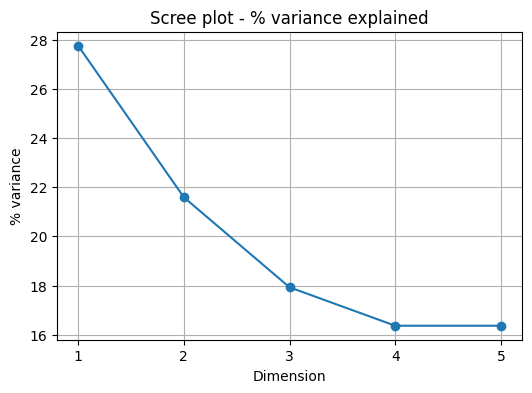

In [110]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(eigvals)+1), perc_var, marker='o', linestyle='-')
plt.title("Scree plot - % variance explained")
plt.xlabel("Dimension")
plt.ylabel("% variance")
plt.xticks(range(1, len(eigvals)+1))
plt.grid(True)
plt.show()


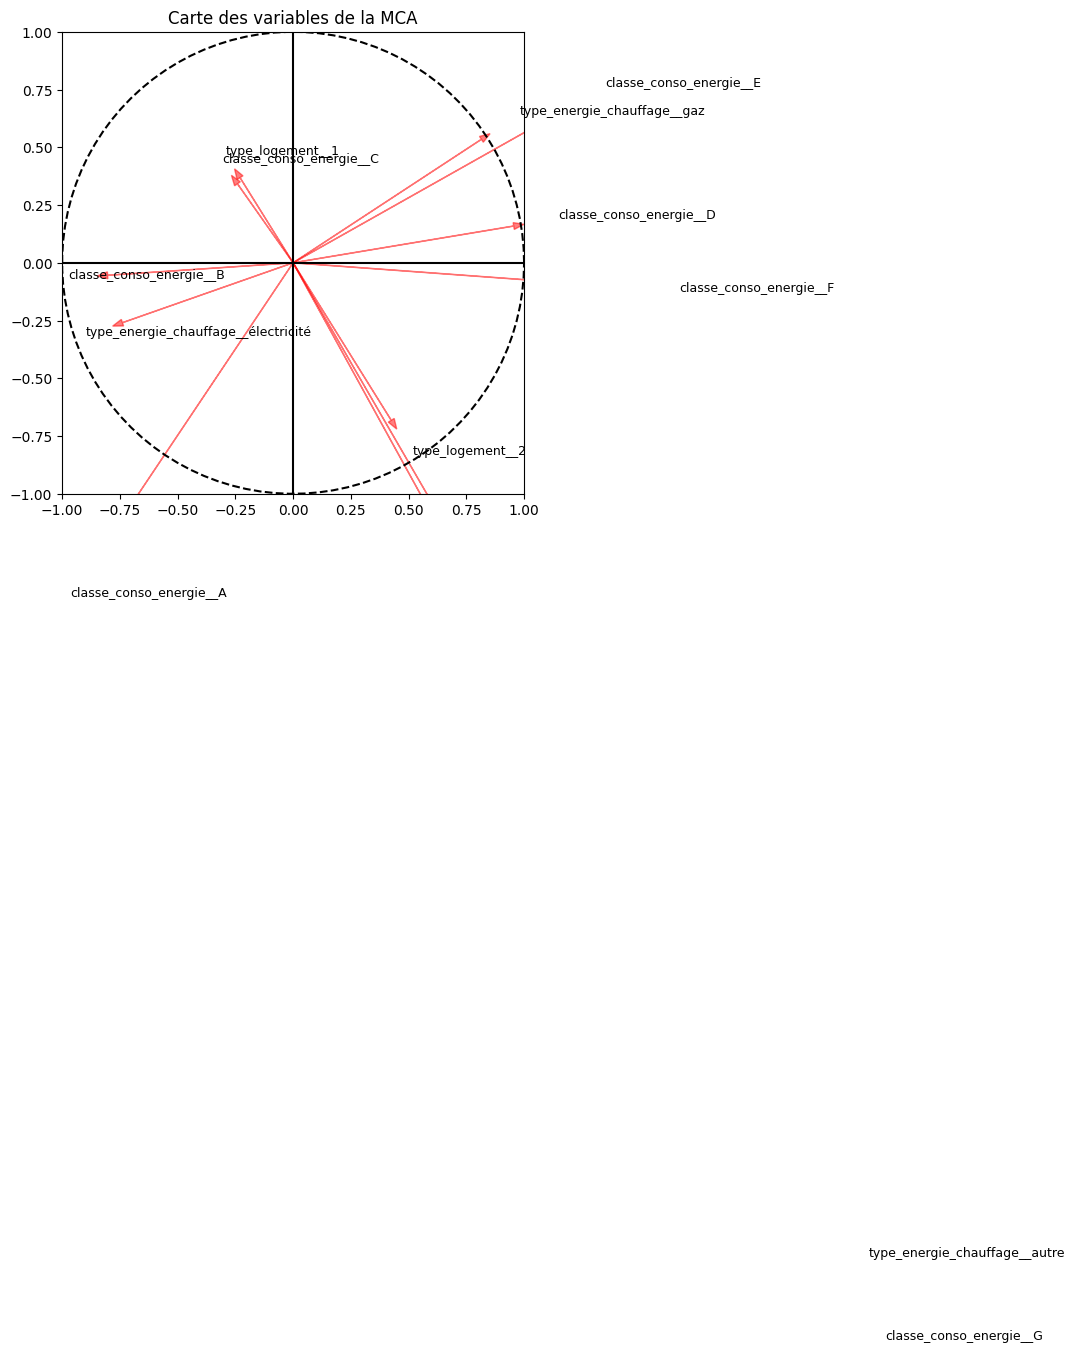

In [114]:
var_coords = mca.column_coordinates(data2)  # coordinates of variables

plt.figure(figsize=(6,6))
for i, var in enumerate(var_coords.index):
    plt.arrow(0, 0, var_coords.iloc[i,0], var_coords.iloc[i,1], 
              color='red', alpha=0.5, head_width=0.03, length_includes_head=True)
    plt.text(var_coords.iloc[i,0]*1.15, var_coords.iloc[i,1]*1.15, var, fontsize=9)

# Vẽ unit circle
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='black')

plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlim(-1,1)
plt.ylim(-1,1)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Carte des variables de la MCA")
plt.show()

##### Interprétation de l'Analyse des Correspondances Multiples (ACM)

### 1. Analyse des axes factoriels
- **Axe 1 (Horizontal)** : Cet axe semble opposer les classes de consommation énergétique. On observe une transition de la gauche vers la droite, allant des bâtiments les plus économes (*Classe B, C*) vers les bâtiments les plus énergivores (*Classe E, F*).

- **Axe 2 (Vertical)** : Cet axe semble structurer les types de logements et les modes de chauffage. Il oppose principalement les appartements (en haut) aux maisons individuelles (en bas).

### 2. Corrélations et Proximités (Associations)
L'analyse des proximités entre les points permet de dégager les profils suivants :

- **Profil "Appartement Économe"** : On observe une proximité entre *type_logement_1* (Appartement) et *classe_conso_energie_C*. Cela suggère que, dans ce jeu de données, les appartements ont tendance à être mieux classés énergétiquement que la moyenne.

- **Profil "Maison Individuelle"** : *type_logement_2* (Maison) se situe dans la partie inférieure du plan. Sa position s'éloigne des classes les plus performantes (*B, C*), ce qui pourrait indiquer une consommation plus élevée ou une isolation différente.

- **Impact du type de chauffage** :
  - *Chauffage Électricité* (*type_energie_chauffage_2*) est graphiquement proche de la *Classe B*, suggérant une corrélation entre les logements tout-électrique (souvent plus récents ou mieux isolés) et une bonne performance énergétique.
  - *Chauffage Gaz* (*type_energie_chauffage_1*) se projette davantage vers la droite du graphique, proche des *Classes D et E*, indiquant une performance énergétique souvent moindre pour ces installations.

### 3. Synthèse des résultats
- Note : Les modalités *classe_conso_energie_E* et *F* sont très excentrées sur la droite. Cela signifie qu'elles contribuent fortement à la formation du premier axe et qu'elles représentent des profils de consommation très distincts (passoires thermiques) par rapport au reste de l'échantillon.